In [1]:
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import os
import matplotlib.cm as cm

from scipy.interpolate import make_interp_spline, BSpline


path = "/Users/sudirekci/Documents/MATLAB/weak_measurements/data/"
colors = cm.get_cmap('tab20b')

# Enable LaTeX font rendering in matplotlib
plt.rcParams.update({
    "figure.dpi":200,
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "axes.labelsize": 14,
    "font.size": 12,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.framealpha": 0.8,
    "lines.markersize":10,
    "grid.alpha": 0.5,
    "legend.handlelength": 1
})


def mat_to_numpy(file_path):
    """
    Loads a .mat file and returns a dictionary where keys are variable names
    and values are NumPy arrays.
    
    Parameters:
        file_path (str): Path to the .mat file.
    
    Returns:
        dict: A dictionary of variable names and corresponding NumPy arrays.
    """
    try:
        raw_data = loadmat(file_path)
    except Exception as e:
        raise ValueError(f"Could not load file '{file_path}': {e}")
    
    # Filter out MATLAB metadata and keep only actual arrays
    data_dict = {
        key: np.array(value)
        for key, value in raw_data.items()
        if not key.startswith('__') and isinstance(value, np.ndarray)
    }
    
    return data_dict


def smooth_data(x, data, pts, interp_degree):
    
    xnew = np.linspace(x.min(), x.max(), pts) 

    spl = make_interp_spline(x, data, k=interp_degree)  # type: BSpline
    data_smooth = spl(xnew)

    return xnew, data_smooth

/var/folders/3z/pb60y4z93gg4zjdk65f3n3kr0000gn/T/ipykernel_69149/2474637388.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20b')


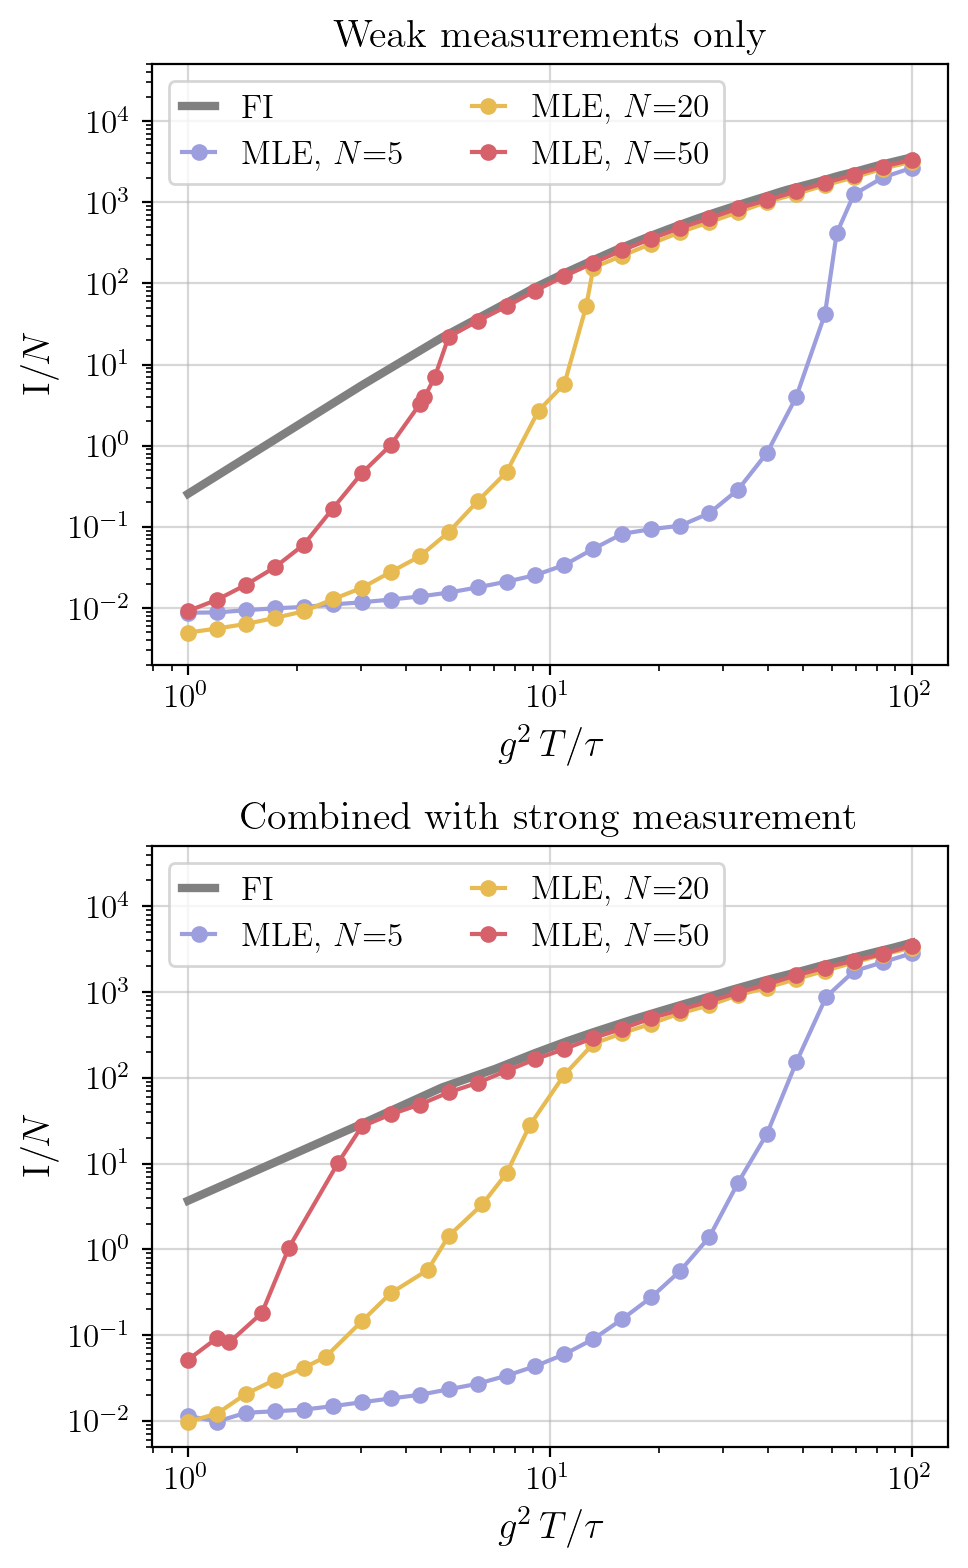

In [16]:
data = mat_to_numpy(path + "fisher_info_no_strong.mat")
T_arr_fisher_weak = np.squeeze(np.asarray(data.get("T_arr_fisher")))
total_fisher_weak = np.squeeze(np.asarray(data.get("total_fisher_info")))

data = mat_to_numpy(path + "fisher_info_with_strong.mat")
T_arr_fisher_strong = np.squeeze(np.asarray(data.get("T_arr_fisher")))
total_fisher_strong  = np.squeeze(np.asarray(data.get("total_fisher_info")))

data = mat_to_numpy(path + "mle_variance_no_strong_5_atoms.mat")
T_arr_5_weak = np.squeeze(np.asarray(data.get("T_arr_mle")))
mle_5_weak = np.squeeze(np.asarray(data.get("mle_variance")))

data = mat_to_numpy(path + "mle_variance_no_strong_20_atoms.mat")
T_arr_20_weak = np.squeeze(np.asarray(data.get("T_arr_mle")))
mle_20_weak = np.squeeze(np.asarray(data.get("mle_variance")))

data = mat_to_numpy(path + "mle_variance_no_strong_50_atoms.mat")
T_arr_50_weak = np.squeeze(np.asarray(data.get("T_arr_mle")))
mle_50_weak = np.squeeze(np.asarray(data.get("mle_variance")))

data = mat_to_numpy(path + "mle_variance_with_strong_5_atoms.mat")
T_arr_5_strong = np.squeeze(np.asarray(data.get("T_arr_mle")))
mle_5_strong = np.squeeze(np.asarray(data.get("mle_variance")))

data = mat_to_numpy(path + "mle_variance_with_strong_20_atoms.mat")
T_arr_20_strong = np.squeeze(np.asarray(data.get("T_arr_mle")))
mle_20_strong = np.squeeze(np.asarray(data.get("mle_variance")))

data = mat_to_numpy(path + "mle_variance_with_strong_50_atoms.mat")
T_arr_50_strong = np.squeeze(np.asarray(data.get("T_arr_mle")))
mle_50_strong = np.squeeze(np.asarray(data.get("mle_variance")))

T_arr_fisher_weak_new, total_fisher_weak_smooth = smooth_data(T_arr_fisher_weak, \
                                                         total_fisher_weak, 50, 1)
T_arr_fisher_strong_new, total_fisher_strong_smooth = smooth_data(T_arr_fisher_strong, \
                                                         total_fisher_strong, 50, 1)
T_arr_5_weak_new, mle_5_weak_smooth = smooth_data(T_arr_5_weak, \
                                                         mle_5_weak, 25, 1)


fig = plt.figure(figsize=(5,8))
ax = fig.add_subplot(2, 1, 1)
plt.plot(T_arr_fisher_weak_new, total_fisher_weak_smooth, \
         label=r'FI', color="gray", linewidth=3)
# plt.plot(T_arr_5_weak_new, np.log(1/(mle_5_weak_smooth*5)), \
#         label=r'FI_w', color='red', linewidth=2)
plt.plot(T_arr_5_weak, 1/(mle_5_weak*5), \
         label=r'MLE, $N$=5', color=colors(3), linewidth=1.5, marker=".")
plt.plot(T_arr_20_weak, 1/(mle_20_weak*20), \
         label=r'MLE, $N$=20', color=colors(10), linewidth=1.5, marker=".")
plt.plot(T_arr_50_weak, 1/(mle_50_weak*50), \
         label=r'MLE, $N$=50', color=colors(14), linewidth=1.5, marker=".")

# Labels and title
ax.set_xlabel(r'$g^2 \, T/\tau$')
ax.set_ylabel(r'I$/N$')
ax.set_title(r'Weak measurements only')
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim([2e-3, 5e4])

plt.legend(loc='upper left', ncol=2)
plt.grid(True)

ax = fig.add_subplot(2, 1, 2)
plt.plot(T_arr_fisher_strong_new, total_fisher_strong_smooth, \
         label=r'FI', color="gray", linewidth=3)
# plt.plot(T_arr_5_weak_new, np.log(1/(mle_5_weak_smooth*5)), \
#         label=r'FI_w', color='red', linewidth=2)
plt.plot(T_arr_5_strong, 1/(mle_5_strong*5), \
         label=r'MLE, $N$=5', color=colors(3), linewidth=1.5, marker=".")
plt.plot(T_arr_20_strong, 1/(mle_20_strong*20), \
         label=r'MLE, $N$=20', color=colors(10), linewidth=1.5, marker=".")
plt.plot(T_arr_50_strong, 1/(mle_50_strong*50), \
         label=r'MLE, $N$=50', color=colors(14), linewidth=1.5, marker=".")

ax.set_xlabel(r'$g^2 \, T/\tau$')
ax.set_ylabel(r'I$/N$')
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim([5e-3, 5e4])
ax.set_title(r'Combined with strong measurement')


# Legend and grid
plt.legend(loc='upper left', ncol=2)
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

In [211]:
T_arr_50_strong

array([  1.        ,   1.20226443,   1.44543977,   1.73780083,
         2.08929613,   2.51188643,   3.01995172,   3.63078055,
         4.36515832,   5.2480746 ,   6.30957344,   7.58577575,
         9.12010839,  10.96478196,  13.18256739,  15.84893192,
        19.05460718,  22.90867653,  27.54228703,  33.11311215,
        39.81071706,  47.86300923,  57.54399373,  69.18309709,
        83.17637711, 100.        ])

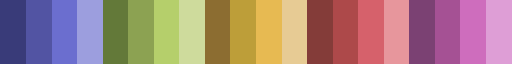

In [212]:
colors